# Berlekamp Algorithm — Polynomial Factorisation over Finite Fields

**Bachelor's Thesis in Mathematics | Universidad de Valladolid (2026)**  
**Author:** David García García  
**Grade: 9/10**

---

## Overview

This notebook contains a complete Python implementation of the **Berlekamp algorithm** for factoring polynomials over finite fields $\mathbb{F}_p$, where $p$ is a **prime number**.

> ⚠️ **Scope and limitations:**  
> - This implementation works over $\mathbb{F}_p$ for **prime** $p$ only (not over general $\mathbb{F}_q$ with $q = p^m$, $m > 1$).  
> - The algorithm is designed for **square-free** polynomials (no repeated irreducible factors).  
> - If the input polynomial has repeated factors — including the special case where $f'(x) = 0$ — the program detects this automatically, extracts the square-free part, and factors that instead.

The algorithm has direct applications in:
- **Cryptography** (RSA, elliptic curve cryptography)
- **Error-correcting codes** (Reed-Solomon, BCH codes)
- **Computer algebra systems**

---

## Polynomial Representation

Polynomials are represented as lists of coefficients in **ascending degree order**:

$$[a_0, a_1, a_2, \ldots, a_n] \quad \text{represents} \quad a_0 + a_1 x + a_2 x^2 + \cdots + a_n x^n$$

**Example:** $x^2 + 3x + 2$ is stored as `[2, 3, 1]`

All coefficients are reduced modulo $p$.

---

## Algorithm Structure

| Block | Description |
|-------|-------------|
| 1 | Polynomial representation and zero-stripping |
| 2 | Arithmetic in $\mathbb{F}_p[x]$: addition, subtraction, multiplication |
| 3 | Euclidean division and GCD |
| 4 | Modular exponentiation |
| 5 | Formal derivative, zero-derivative case ($f'=0$), and square-free extraction |
| 6 | Berlekamp matrix construction |
| 7 | Kernel computation via Gauss-Jordan elimination |
| 8 | Berlekamp factorisation |
| 9 | Output utilities and `factorise_and_print` pipeline |
| — | **Interactive mode** (optional, prompts for input) |
| 10 | Examples (thesis + zero-derivative cases) |
| 11 | Performance analysis (time vs degree and prime) |
| 12 | Large-scale examples |

In [1]:
# ============================================================
# FACTORISATION IN F_p[x] USING THE BERLEKAMP ALGORITHM
# ============================================================
#
# IMPORTANT RESTRICTIONS:
#   - p must be a prime number (not a prime power q = p^m with m > 1).
#   - The algorithm is designed for square-free polynomials.
#     If the input has repeated factors, the program extracts the
#     square-free part — including the special case f'(x) = 0.
#
# Polynomials are represented as lists of coefficients
# in ASCENDING degree order:
#   [a0, a1, a2, ..., an]  represents  a0 + a1*x + a2*x^2 + ... + an*x^n
#
# Example: x^2 + 3x + 2  is stored as  [2, 3, 1]
# ============================================================


# ------------------------------------------------------------
# BLOCK 1: POLYNOMIAL REPRESENTATION AND ZERO-STRIPPING
# ------------------------------------------------------------

def poly_strip(p_poly):
    # Removes trailing zero coefficients to maintain the true degree.
    # For example [1, 2, 0, 0] -> [1, 2] (represents 1 + 2x, degree 1).
    # At least one element is kept to represent the zero polynomial [0].
    while len(p_poly) > 1 and p_poly[-1] == 0:
        p_poly.pop()
    return p_poly


# ------------------------------------------------------------
# BLOCK 2: ARITHMETIC IN F_p[x]: ADDITION, SUBTRACTION, MULTIPLICATION
# ------------------------------------------------------------

def poly_add(a, b, p):
    # Addition a(x) + b(x) in F_p[x]: add term by term, reduce mod p.
    n = max(len(a), len(b))
    r = [0] * n
    for i in range(n):
        if i < len(a): r[i] = (r[i] + a[i]) % p
        if i < len(b): r[i] = (r[i] + b[i]) % p
    return poly_strip(r)


def poly_sub(a, b, p):
    # Subtraction a(x) - b(x) in F_p[x].
    # Reduction mod p keeps all coefficients in {0, ..., p-1}.
    n = max(len(a), len(b))
    r = [0] * n
    for i in range(n):
        if i < len(a): r[i] = (r[i] + a[i]) % p
        if i < len(b): r[i] = (r[i] - b[i]) % p
    return poly_strip(r)


def poly_mul(a, b, p):
    # Product a(x)*b(x) in F_p[x] via coefficient convolution.
    # Coefficient of x^k = sum of a[i]*b[j] for all i+j = k.
    r = [0] * (len(a) + len(b) - 1)
    for i in range(len(a)):
        for j in range(len(b)):
            r[i + j] = (r[i + j] + a[i] * b[j]) % p
    return poly_strip(r)


# ------------------------------------------------------------
# BLOCK 3: EUCLIDEAN DIVISION IN F_p[x] AND GREATEST COMMON DIVISOR
# ------------------------------------------------------------

def poly_divmod(a, b, p):
    """
    Division with remainder of a(x) by b(x) in F_p[x].
    Returns (c, r) such that: a(x) = c(x)*b(x) + r(x), deg(r) < deg(b).
    """
    a = poly_strip(a[:])
    b = poly_strip(b)
    m, n = len(a) - 1, len(b) - 1

    if b == [0]:
        raise ZeroDivisionError("Division by the zero polynomial.")
    if m < n:
        return [0], a

    inv_lc = pow(b[-1], -1, p)  # inverse of leading coefficient of b
    c = [0] * (m - n + 1)

    for k in range(m - n, -1, -1):
        c[k] = (a[n + k] * inv_lc) % p
        for j in range(n + k, k - 1, -1):
            a[j] = (a[j] - c[k] * b[j - k]) % p

    return poly_strip(c), poly_strip(a)


def poly_gcd(a, b, p):
    # GCD of a(x) and b(x) via Euclidean algorithm. Result is monic.
    a, b = poly_strip(a), poly_strip(b)
    while b != [0]:
        _, r = poly_divmod(a, b, p)
        a, b = b, r
    inv = pow(a[-1], -1, p)
    return [(c * inv) % p for c in a]


# ------------------------------------------------------------
# BLOCK 4: MODULAR EXPONENTIATION — base^n mod f(x) in F_p[x]
# ------------------------------------------------------------

def poly_mod_pow(base, n, f, p):
    """
    Computes base^n mod f(x) in F_p[x] using binary exponentiation.
    Used to compute x^(p*i) mod f(x) for the Berlekamp matrix.
    """
    r = [1]
    b = base[:]
    while n > 0:
        if n & 1:
            r = poly_divmod(poly_mul(r, b, p), f, p)[1]
        b = poly_divmod(poly_mul(b, b, p), f, p)[1]
        n >>= 1
    return poly_strip(r)


# ------------------------------------------------------------
# BLOCK 5: FORMAL DERIVATIVE, ZERO-DERIVATIVE CASE, SQUARE-FREE EXTRACTION
# ------------------------------------------------------------

def poly_deriv(pol, p):
    # Formal derivative of pol(x) in F_p[x].
    # In characteristic p, the derivative of a_i*x^i is i*a_i*x^(i-1).
    # Terms with i divisible by p vanish (i ≡ 0 mod p).
    if len(pol) <= 1:
        return [0]
    return poly_strip([(i * pol[i]) % p for i in range(1, len(pol))])


def poly_pth_root(f, p):
    """
    Given f(x) with f'(x) = 0, extracts g(x) such that f(x) = g(x^p).

    When f'(x) = 0 in characteristic p, every exponent in f is a
    multiple of p, so:
        f(x) = a_0 + a_p*x^p + a_{2p}*x^{2p} + ... = g(x^p)
    where g(x) = a_0 + a_p*x + a_{2p}*x^2 + ...

    By the Frobenius endomorphism, (a)^p = a for all a in F_p, so:
        g(x^p) = g(x)^p
    meaning f is a perfect p-th power. To factor f, we factor g.
    """
    for i in range(len(f)):
        if f[i] != 0 and i % p != 0:
            raise ValueError("poly_pth_root: polynomial is not a p-th power.")
    # Extract coefficients at positions 0, p, 2p, ...
    g = [f[i] for i in range(0, len(f), p)]
    return poly_strip(g)


def es_primo(n):
    # Primality check by trial division.
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0: return False
    return True


def make_squarefree(f, p):
    """
    Returns the square-free part of f(x) in F_p[x].

    Handles two cases:

    CASE A — f'(x) ≠ 0 (standard):
        d = gcd(f, f'). If d = 1, f is square-free.
        Otherwise the square-free part is f / d.

    CASE B — f'(x) = 0 (characteristic p, zero derivative):
        Every exponent in f is a multiple of p, so f(x) = g(x^p) = g(x)^p.
        We extract g via poly_pth_root and apply make_squarefree recursively.
        This handles arbitrarily deep nesting (e.g. f = h^(p^k)).

        Example in F_2: f(x) = x^4 + 1
            f'(x) = 4x^3 = 0  ->  g(x) = x^2 + 1
            g'(x) = 2x = 0   ->  h(x) = x + 1
            h'(x) = 1 ≠ 0, gcd(h, h') = 1  ->  square-free part = (x+1)
            Final: f(x) = (x+1)^4
    """
    f = poly_strip(f[:])
    df = poly_deriv(f, p)

    # CASE B: zero derivative
    if df == [0]:
        g = poly_pth_root(f, p)   # f(x) = g(x^p) = g(x)^p
        return make_squarefree(g, p)  # recurse on g

    # CASE A: standard gcd-based extraction
    d = poly_gcd(f, df, p)
    if d == [1]:
        return f
    quotient, _ = poly_divmod(f, d, p)
    return poly_strip(quotient)


# ------------------------------------------------------------
# BLOCK 6: CONSTRUCTION OF THE BERLEKAMP MATRIX Q
# ------------------------------------------------------------

def berlekamp_matrix(f, p):
    """
    Builds the n×n Berlekamp matrix Q for f(x) of degree n.

    Column i contains the coefficients of x^(p*i) mod f(x)
    in the basis {1, x, ..., x^(n-1)} of F_p[x]/(f).

    This encodes the Frobenius automorphism (x -> x^p) on F_p[x]/(f).
    The kernel of (Q - I) determines the factorisation of f.
    """
    n = len(f) - 1
    Q = [[0] * n for _ in range(n)]
    x = [0, 1]
    for i in range(n):
        h = poly_mod_pow(x, p * i, f, p)
        for j in range(n):
            Q[j][i] = h[j] if j < len(h) else 0
    return Q


# ------------------------------------------------------------
# BLOCK 7: KERNEL OF (Q - I) VIA GAUSS-JORDAN ELIMINATION
# ------------------------------------------------------------

def kernel_mod_Q(A, p):
    """
    Returns a basis for the kernel of (A - I) over F_p.

    The dimension k of this kernel equals the number of distinct
    irreducible factors of f. Each basis vector h_i(x) is used
    to split factors in the Berlekamp step.
    """
    n = len(A)
    B = [[(A[i][j] - (1 if i == j else 0)) % p for j in range(n)]
         for i in range(n)]

    piv = 0
    pivcol = []

    for j in range(n):
        for i in range(piv, n):
            if B[i][j] != 0:
                B[piv], B[i] = B[i], B[piv]
                inv = pow(B[piv][j], -1, p)
                B[piv] = [(x * inv) % p for x in B[piv]]
                for r in range(n):
                    if r != piv and B[r][j] != 0:
                        fac = B[r][j]
                        B[r] = [(B[r][k] - fac * B[piv][k]) % p for k in range(n)]
                pivcol.append(j)
                piv += 1
                break

    free = [j for j in range(n) if j not in pivcol]
    basis = []
    for fcol in free:
        v = [0] * n
        v[fcol] = 1
        for i, c in enumerate(pivcol):
            v[c] = (-B[i][fcol]) % p
        basis.append(v)
    return basis


# ------------------------------------------------------------
# BLOCK 8: BERLEKAMP FACTORISATION
# ------------------------------------------------------------

def berlekamp_factor(f, p):
    """
    Factorises f(x) in F_p[x] using the Berlekamp algorithm.

    PRECONDITIONS (caller's responsibility):
      - p must be prime.
      - f must be square-free. Use make_squarefree(f, p) if needed.

    Steps:
      1. Build Q (Berlekamp matrix).
      2. Compute basis of ker(Q - I). Its dimension k = number of factors.
      3. If k = 1: f is irreducible.
      4. If k >= 2: use each h_i to split factors via gcd(f, h_i - c).
    """
    f = poly_strip(f)
    if len(f) <= 2:
        return [f]

    Q = berlekamp_matrix(f, p)
    ker = kernel_mod_Q(Q, p)

    if len(ker) == 1:
        return [f]

    factors = [f]
    for v in ker[1:]:
        h = v[:]
        new = []
        for g in factors:
            if len(g) <= 2:
                new.append(g)
                continue
            hmod = poly_divmod(h, g, p)[1]
            split = False
            for c in range(p):
                d = poly_gcd(g, poly_sub(hmod, [c], p), p)
                if d != [1] and d != g:
                    new.append(d)
                    new.append(poly_divmod(g, d, p)[0])
                    split = True
                    break
            if not split:
                new.append(g)
        factors = new

    return factors


# ------------------------------------------------------------
# BLOCK 9: OUTPUT UTILITIES AND INTERACTIVE MAIN PROGRAM
# ------------------------------------------------------------

def poly_to_str(pol, p):
    # Converts polynomial to readable string: ax^n + ... + bx + c.
    # Zero coefficients are omitted. Leading coefficient 1 is suppressed.
    terms = []
    for i in range(len(pol) - 1, -1, -1):
        a = pol[i] % p
        if a == 0: continue
        if i == 0:
            terms.append(str(a))
        elif i == 1:
            terms.append(f"{a}x" if a != 1 else "x")
        else:
            terms.append(f"{a}x^{i}" if a != 1 else f"x^{i}")
    return " + ".join(terms) if terms else "0"


def factorise_and_print(f_input, p):
    """
    Full pipeline: validate, handle repeated factors (including f'=0 case),
    run Berlekamp, and print the result.

    Parameters
    ----------
    f_input : list of int  — coefficients in ascending degree order
    p : int               — prime defining F_p
    """
    if not es_primo(p):
        raise ValueError(f"{p} is not prime. Berlekamp requires prime p.")

    f = poly_strip(f_input[:])
    print(f"Field: F_{p}")
    print(f"f(x) = {poly_to_str(f, p)}")

    df = poly_deriv(f, p)
    if df == [0]:
        print(f"  f'(x) = 0: every exponent is a multiple of {p}.")
        print(f"  => f(x) = g(x^{p}) = g(x)^{p} for some g(x).")
        print(f"  => Extracting g and factoring its square-free part recursively.")

    f_sf = make_squarefree(f, p)

    if f_sf != f:
        print(f"  [Repeated factors detected. Square-free part: {poly_to_str(f_sf, p)}]")
        print(f"  [Multiplicities not recovered — Berlekamp factors square-free polynomials only.]")

    factors = berlekamp_factor(f_sf, p)

    print("Result:")
    print("  " + poly_to_str(f_sf, p) + "  =  "
          + "  *  ".join(f"({poly_to_str(g, p)})" for g in factors))
    print()

---

## Block 10 — Examples

The following cells reproduce the examples worked out in the thesis (Chapter 4),  
plus two additional cases illustrating the zero-derivative situation.

Run each cell independently after running the main code cell above.

| # | Field | Polynomial | Case |
|---|-------|------------|------|
| 1 | $\mathbb{F}_2$ | $x^{12} + x^9 + x^6 + x^3 + 1$ | Standard (square-free) |
| 2 | $\mathbb{F}_5$ | $x^5 + x^4 + x^3 + x^2 + x + 1$ | Standard (square-free) |
| 3 | $\mathbb{F}_2$ | $x^4 + 1$ | $f'=0$: $f = (x+1)^4$ |
| 4 | $\mathbb{F}_3$ | $x^6 + 2x^3 + 1$ | $f'=0$: $f = (x+1)^6$ |

In [2]:
# Example 1 — F_2[x], degree 12  (thesis Section 4.3.1)
# f(x) = x^12 + x^9 + x^6 + x^3 + 1
factorise_and_print([1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1], p=2)

Field: F_2
f(x) = x^12 + x^9 + x^6 + x^3 + 1
Result:
  x^12 + x^9 + x^6 + x^3 + 1  =  (x^4 + x + 1)  *  (x^4 + x^3 + x^2 + x + 1)  *  (x^4 + x^3 + 1)



In [3]:
# Example 2 — F_5[x], degree 5  (thesis Section 4.3.2)
# f(x) = x^5 + x^4 + x^3 + x^2 + x + 1
factorise_and_print([1, 1, 1, 1, 1, 1], p=5)

Field: F_5
f(x) = x^5 + x^4 + x^3 + x^2 + x + 1
Result:
  x^5 + x^4 + x^3 + x^2 + x + 1  =  (x^2 + x + 1)  *  (x + 1)  *  (x^2 + 4x + 1)



In [4]:
# Example 3 — Zero derivative case in F_2[x]
#
# f(x) = x^4 + 1
# f'(x) = 4x^3 = 0 in F_2
# => f(x) = g(x^2) with g(x) = x^2 + 1
# g'(x) = 2x = 0 in F_2
# => g(x) = h(x^2) with h(x) = x + 1  (square-free, h'=1 != 0)
# => f(x) = (x+1)^4
factorise_and_print([1, 0, 0, 0, 1], p=2)

Field: F_2
f(x) = x^4 + 1
  f'(x) = 0: every exponent is a multiple of 2.
  => f(x) = g(x^2) = g(x)^2 for some g(x).
  => Extracting g and factoring its square-free part recursively.
  [Repeated factors detected. Square-free part: x + 1]
  [Multiplicities not recovered — Berlekamp factors square-free polynomials only.]
Result:
  x + 1  =  (x + 1)



In [5]:
# Example 4 — Zero derivative case in F_3[x]
#
# f(x) = x^6 + 2x^3 + 1
# f'(x) = 6x^5 + 6x^2 = 0 in F_3
# => f(x) = g(x^3) with g(x) = x^2 + 2x + 1 = (x+1)^2
# gcd(g, g') = gcd(x^2+2x+1, 2x+2) = (x+1)  -> g is NOT square-free
# square-free part of g = x + 1
# => square-free part of f = x + 1,  and  f(x) = (x+1)^6
factorise_and_print([1, 0, 0, 2, 0, 0, 1], p=3)

Field: F_3
f(x) = x^6 + 2x^3 + 1
  f'(x) = 0: every exponent is a multiple of 3.
  => f(x) = g(x^3) = g(x)^3 for some g(x).
  => Extracting g and factoring its square-free part recursively.
  [Repeated factors detected. Square-free part: x + 1]
  [Multiplicities not recovered — Berlekamp factors square-free polynomials only.]
Result:
  x + 1  =  (x + 1)



---

## Block 11 — Performance Analysis

The cells below measure how execution time scales with the **degree** $n$ of the polynomial
and the **prime** $p$ defining the field.

This connects directly with the complexity analysis in **Appendix A** of the thesis.

### Cost of each phase

| Phase | Cost |
|-------|------|
| Square-free decomposition $\gcd(f, f')$ | $O(n^2)$ |
| Berlekamp matrix construction | $O(n^3)$ |
| Kernel of $B - I$ (Gaussian elimination) | $O(n^3)$ |
| Factor separation via $\gcd(f, h - c)$ | $O(qn^2)$ |

### Total complexity

$$T(n, q) = \underbrace{O(n^3)}_{\text{matrix + kernel}} + \underbrace{O(qn^2)}_{\text{factor separation}}$$

### When does each term dominate?

| Situation | Dominant term | Real example |
|-----------|--------------|---------------|
| $q \ll n$ | $O(n^3)$ | Binary BCH codes ($q=2$, $n \approx 100$) |
| $q \gg n$ | $O(qn^2)$ | Arithmetic over $\mathbb{F}_{2^{16}}$ (CRC, digital hardware) |


> ⚠️ Timings are averaged over multiple runs on random square-free polynomials.
> Results may vary depending on hardware and the specific polynomial structure.

Experiment 1: varying degree (p=7)...
  deg=5: 0ms
  deg=15: 2ms
  deg=25: 8ms
  deg=35: 22ms
  deg=45: 46ms
  deg=55: 84ms
  deg=65: 139ms
  deg=75: 206ms
  deg=85: 293ms
  deg=95: 415ms
  deg=105: 556ms
  deg=115: 741ms
  deg=125: 982ms
  deg=135: 1208ms
  deg=145: 1484ms

Experiment 2: varying prime (n=80)...
  p=2: 74ms
  p=3: 124ms
  p=5: 194ms
  p=7: 245ms
  p=11: 321ms
  p=17: 389ms
  p=23: 456ms
  p=31: 542ms
  p=41: 606ms
  p=53: 686ms
  p=67: 744ms
  p=79: 738ms
  p=97: 778ms
  p=127: 953ms
  p=157: 902ms
  p=199: 1025ms
  p=251: 996ms
  p=307: 1162ms
  p=401: 1413ms
  p=503: 1530ms

Experiment 3: heatmap...
  deg=10 done
  deg=20 done
  deg=30 done
  deg=40 done
  deg=50 done
  deg=60 done
  deg=70 done
  deg=80 done
  deg=90 done
  deg=100 done


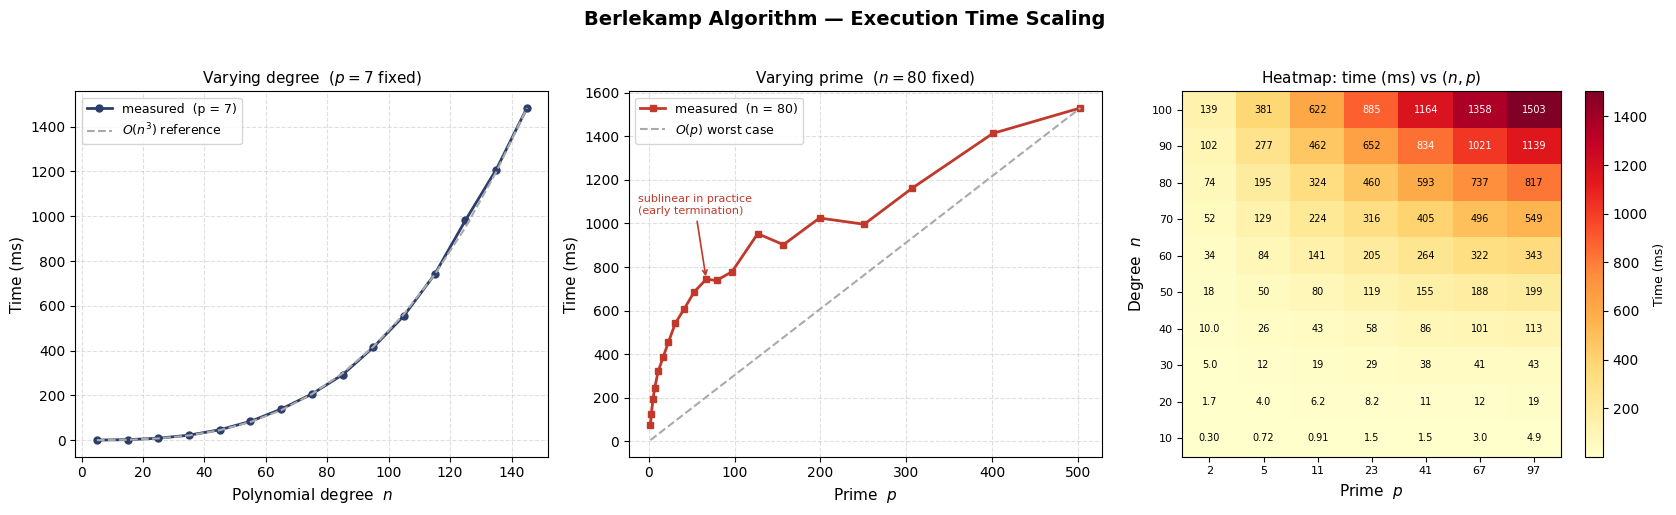


Key observations:
  1. Degree: grows from 0ms (deg=5) to 1484ms (deg=145).
     Fits O(n^3) closely — both matrix construction and Gauss-Jordan
     contribute O(n^3) as derived in the thesis.

  2. Prime: grows from 74ms (p=2) to 1530ms (p=503).
     Growth is sublinear in p — the O(qn^2) bound is a worst case.
     In practice the GCD splitting step terminates early (first c
     in F_p that splits the factor), so the average cost is much lower.

  3. Heatmap: top-right corner (large n + large p) is the real bottleneck.
     Max measured: 1503ms at deg=100, p=97.


In [6]:
import time
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── Helpers ──────────────────────────────────────────────────────────────

def random_squarefree_poly(deg, p, seed=None):
    """Generate a random square-free monic polynomial of given degree over F_p."""
    rng = random.Random(seed)
    for _ in range(300):
        coeffs = [rng.randint(0, p - 1) for _ in range(deg)] + [1]
        f = poly_strip(coeffs)
        if make_squarefree(f, p) == f:
            return f
    return poly_strip(coeffs)


def measure(f, p, reps=4):
    """Return average execution time of berlekamp_factor(f, p) in milliseconds."""
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        berlekamp_factor(f[:], p)
        times.append((time.perf_counter() - t0) * 1000)
    times.sort()
    return np.mean(times[1:-1])  # discard best and worst


# ── Experiment 1: fixed p, varying n ─────────────────────────────────────
# Dominant term: O(n^3) — matrix construction + Gauss-Jordan kernel
# Range: up to degree 150 (~1.5s) so the cubic growth is clearly visible

P_FIXED = 7
DEGREES = list(range(5, 151, 10))   # 5, 15, 25, ..., 145

print("Experiment 1: varying degree (p=7)...")
times_n = []
for deg in DEGREES:
    f = random_squarefree_poly(deg, P_FIXED, seed=42 + deg)
    t = measure(f, P_FIXED)
    times_n.append(t)
    print(f"  deg={deg}: {t:.0f}ms")


# ── Experiment 2: fixed n, varying p ─────────────────────────────────────
# Worst-case: O(p*n^2). In practice sublinear in p due to early termination
# of the GCD splitting step (first c in F_p that splits the factor).
# n=80, p up to 503 gives ~1.5s at the top end.

N_FIXED = 80
PRIMES  = [2, 3, 5, 7, 11, 17, 23, 31, 41, 53, 67, 79, 97,
           127, 157, 199, 251, 307, 401, 503]

print("\nExperiment 2: varying prime (n=80)...")
times_p = []
for pr in PRIMES:
    f = random_squarefree_poly(N_FIXED, pr, seed=99 + pr)
    t = measure(f, pr)
    times_p.append(t)
    print(f"  p={pr}: {t:.0f}ms")


# ── Experiment 3: heatmap — both n and p vary ────────────────────────────
# Range chosen so that the top-right corner (large n + large p)
# reaches ~1-2s, clearly showing the combined bottleneck.

HEAT_DEGS   = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
HEAT_PRIMES = [2, 5, 11, 23, 41, 67, 97]

print("\nExperiment 3: heatmap...")
heat = np.zeros((len(HEAT_DEGS), len(HEAT_PRIMES)))
for i, deg in enumerate(HEAT_DEGS):
    for j, pr in enumerate(HEAT_PRIMES):
        f = random_squarefree_poly(deg, pr, seed=deg * 100 + pr)
        heat[i, j] = measure(f, pr, reps=3)
    print(f"  deg={deg} done")


# ── Plot ─────────────────────────────────────────────────────────────────

BLUE = '#2C3E6B'
RED  = '#C0392B'
GREY = '#AAAAAA'

fig = plt.figure(figsize=(17, 5))
fig.suptitle('Berlekamp Algorithm — Execution Time Scaling',
             fontsize=14, fontweight='bold', y=1.02)

# --- Left: time vs degree (O(n^3) reference) ---
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(DEGREES, times_n, 'o-', color=BLUE, linewidth=2,
         markersize=5, label=f'measured  (p = {P_FIXED})')

x = np.array(DEGREES, dtype=float)
scale3 = times_n[-1] / x[-1]**3
ax1.plot(x, scale3 * x**3, '--', color=GREY, linewidth=1.5,
         label=r'$O(n^3)$ reference')

ax1.set_xlabel('Polynomial degree  $n$', fontsize=11)
ax1.set_ylabel('Time (ms)', fontsize=11)
ax1.set_title(f'Varying degree  ($p = {P_FIXED}$ fixed)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))

# --- Middle: time vs prime ---
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(PRIMES, times_p, 's-', color=RED, linewidth=2,
         markersize=5, label=f'measured  (n = {N_FIXED})')

# O(p) worst-case reference scaled to last point
scale_p = times_p[-1] / PRIMES[-1]
ax2.plot(PRIMES, [scale_p * pr for pr in PRIMES], '--', color=GREY,
         linewidth=1.5, label=r'$O(p)$ worst case')

ax2.set_xlabel('Prime  $p$', fontsize=11)
ax2.set_ylabel('Time (ms)', fontsize=11)
ax2.set_title(f'Varying prime  ($n = {N_FIXED}$ fixed)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))

# Annotate the sublinear gap
mid = len(PRIMES) // 2
ax2.annotate('sublinear in practice\n(early termination)',
             xy=(PRIMES[mid], times_p[mid]),
             xytext=(PRIMES[mid] - 80, times_p[mid] + 300),
             fontsize=8, color=RED,
             arrowprops=dict(arrowstyle='->', color=RED, lw=1.2))

# --- Right: heatmap n x p ---
ax3 = fig.add_subplot(1, 3, 3)
im = ax3.imshow(heat, aspect='auto', cmap='YlOrRd', origin='lower')
cbar = fig.colorbar(im, ax=ax3)
cbar.set_label('Time (ms)', fontsize=9)

ax3.set_xticks(range(len(HEAT_PRIMES)))
ax3.set_xticklabels(HEAT_PRIMES, fontsize=8)
ax3.set_yticks(range(len(HEAT_DEGS)))
ax3.set_yticklabels(HEAT_DEGS, fontsize=8)
ax3.set_xlabel('Prime  $p$', fontsize=11)
ax3.set_ylabel('Degree  $n$', fontsize=11)
ax3.set_title('Heatmap: time (ms) vs $(n, p)$', fontsize=11)

for i in range(len(HEAT_DEGS)):
    for j in range(len(HEAT_PRIMES)):
        val = heat[i, j]
        txt = f'{val:.0f}' if val >= 10 else (f'{val:.1f}' if val >= 1 else f'{val:.2f}')
        color = 'white' if val > heat.max() * 0.55 else 'black'
        ax3.text(j, i, txt, ha='center', va='center',
                 fontsize=7, color=color)

plt.tight_layout()
plt.show()


# ── Key observations ─────────────────────────────────────────────────────
print("\nKey observations:")
print(f"  1. Degree: grows from {times_n[0]:.0f}ms (deg=5) to {times_n[-1]:.0f}ms (deg=145).")
print(f"     Fits O(n^3) closely — both matrix construction and Gauss-Jordan")
print(f"     contribute O(n^3) as derived in the thesis.")
print()
print(f"  2. Prime: grows from {times_p[0]:.0f}ms (p=2) to {times_p[-1]:.0f}ms (p=503).")
print(f"     Growth is sublinear in p — the O(qn^2) bound is a worst case.")
print(f"     In practice the GCD splitting step terminates early (first c")
print(f"     in F_p that splits the factor), so the average cost is much lower.")
print()
print(f"  3. Heatmap: top-right corner (large n + large p) is the real bottleneck.")
print(f"     Max measured: {heat.max():.0f}ms at deg={HEAT_DEGS[np.unravel_index(heat.argmax(), heat.shape)[0]]},"
      f" p={HEAT_PRIMES[np.unravel_index(heat.argmax(), heat.shape)[1]]}.")


---

## Block 12 — Large-Scale Examples

The following examples push the algorithm to higher degrees and larger primes
to demonstrate that it remains practical well beyond the toy examples in the thesis.


In [7]:
import time

# ── Large Example 1 — degree 30 over F_31 ────────────────────────────────
#
# A degree-30 polynomial over the field F_31.
# Constructed as the product of three irreducible factors to guarantee
# the factorisation is non-trivial.
#
# f(x) = (x^10 + 3x^5 + 7) * (x^11 + 5x^3 + 2x + 1) * (x^9 + x + 1)  mod 31

p1 = 31
a = poly_strip([7, 0, 0, 0, 0, 3, 0, 0, 0, 0, 1])   # x^10 + 3x^5 + 7
b = poly_strip([1, 2, 0, 5, 0, 0, 0, 0, 0, 0, 0, 1]) # x^11 + 5x^3 + 2x + 1
c = poly_strip([1, 1, 0, 0, 0, 0, 0, 0, 0, 1])       # x^9 + x + 1
f_large1 = poly_mul(poly_mul(a, b, p1), c, p1)

print(f'Large Example 1 — F_{p1}[x], degree {len(f_large1)-1}')
print(f'f(x) = {poly_to_str(f_large1, p1)}')

t0 = time.perf_counter()
factors1 = berlekamp_factor(make_squarefree(f_large1, p1), p1)
elapsed1 = (time.perf_counter() - t0) * 1000

print(f'\nFactorisation ({elapsed1:.1f} ms):')
for i, g in enumerate(factors1, 1):
    print(f'  Factor {i} (degree {len(g)-1}): {poly_to_str(g, p1)}')
print(f'  Number of irreducible factors found: {len(factors1)}')


print('\n' + '─'*65 + '\n')


# ── Large Example 2 — degree 25 over F_37, random square-free ────────────
#
# A random square-free monic polynomial of degree 25 over F_37.
# This represents a realistic use case where the input structure is unknown.

p2 = 37
f_large2 = random_squarefree_poly(25, p2, seed=2024)

print(f'Large Example 2 — F_{p2}[x], degree {len(f_large2)-1} (random square-free)')
print(f'f(x) = {poly_to_str(f_large2, p2)}')

t0 = time.perf_counter()
factors2 = berlekamp_factor(f_large2, p2)
elapsed2 = (time.perf_counter() - t0) * 1000

print(f'\nFactorisation ({elapsed2:.1f} ms):')
for i, g in enumerate(factors2, 1):
    print(f'  Factor {i} (degree {len(g)-1}): {poly_to_str(g, p2)}')
print(f'  Number of irreducible factors found: {len(factors2)}')


print('\n' + '─'*65 + '\n')


# ── Large Example 3 — irreducibility check, degree 20 over F_19 ──────────
#
# Berlekamp can also verify that a polynomial is irreducible:
# if the kernel of (Q - I) has dimension 1, the polynomial is irreducible.
# Here we search for an irreducible polynomial of degree 20 over F_19.

p3 = 19
target_deg = 20
rng = random.Random(7)

irreducible_found = None
attempts = 0
while irreducible_found is None:
    attempts += 1
    coeffs = [rng.randint(0, p3 - 1) for _ in range(target_deg)] + [1]
    f_candidate = poly_strip(coeffs)
    if make_squarefree(f_candidate, p3) != f_candidate:
        continue   # skip non-square-free
    facs = berlekamp_factor(f_candidate, p3)
    if len(facs) == 1 and len(facs[0]) == len(f_candidate):
        irreducible_found = f_candidate

print(f'Large Example 3 — Irreducibility check in F_{p3}[x]')
print(f'Searched {attempts} random degree-{target_deg} polynomials.')
print(f'Irreducible polynomial found:')
print(f'  f(x) = {poly_to_str(irreducible_found, p3)}')
t0 = time.perf_counter()
_ = berlekamp_factor(irreducible_found, p3)
print(f'  Verified irreducible in {(time.perf_counter()-t0)*1000:.1f} ms')
print(f'  (Berlekamp matrix kernel has dimension 1 — no non-trivial factorisation exists.)')

Large Example 1 — F_31[x], degree 30
f(x) = x^30 + 3x^25 + 6x^22 + x^21 + 9x^20 + x^19 + 18x^17 + 3x^16 + 6x^15 + 8x^14 + 5x^13 + 13x^12 + 10x^11 + 15x^10 + 22x^9 + 15x^8 + 6x^7 + 9x^6 + 3x^5 + 4x^4 + 4x^3 + 14x^2 + 21x + 7

Factorisation (38.2 ms):
  Factor 1 (degree 2): x^2 + 27x + 22
  Factor 2 (degree 6): x^6 + 25x^5 + 27x^4 + 7x^3 + 8x^2 + 5x + 25
  Factor 3 (degree 10): x^10 + 3x^5 + 7
  Factor 4 (degree 4): x^4 + 9x^3 + 5x^2 + 24x + 19
  Factor 5 (degree 1): x + 28
  Factor 6 (degree 1): x + 3
  Factor 7 (degree 6): x^6 + x^5 + 22x^4 + 8x^3 + x^2 + 19x + 8
  Number of irreducible factors found: 7

─────────────────────────────────────────────────────────────────

Large Example 2 — F_37[x], degree 25 (random square-free)
f(x) = x^25 + 3x^24 + 26x^23 + 13x^22 + 34x^21 + 9x^20 + 29x^19 + 13x^18 + 4x^17 + 33x^16 + 21x^15 + 34x^14 + 19x^13 + 13x^12 + 33x^11 + 26x^10 + 22x^9 + 31x^8 + 15x^7 + 34x^6 + 16x^5 + 26x^4 + 12x^3 + 19x^2 + 11x + 30

Factorisation (21.6 ms):
  Factor 1 (degree

---

## Interactive Mode *(optional — run this cell last)*

Use this cell to factor **any polynomial of your choice**.  
You will be prompted to enter the degree, coefficients and prime $p$.

> ⚠️ **Do not include this cell in 'Run All'** — it waits for keyboard input and will block execution.  
> Run it manually only when you want to test a custom polynomial.


In [ ]:
# Interactive mode — run this cell to factor a polynomial of your choice
# (Run the main algorithm cell first)

print("Factorisation in F_p[x]  (enter coefficients from HIGHEST to LOWEST degree)\n")
n      = int(input("Degree of the polynomial: "))
coeffs = list(map(int, input(f"Enter {n+1} coefficients (highest to lowest): ").split()))
p      = int(input("Enter p (prime): "))

if len(coeffs) != n + 1:
    raise ValueError("Incorrect number of coefficients.")

factorise_and_print(poly_strip(list(reversed(coeffs))), p)